In [43]:
# the data contains record of 9800 individuals ,we will be using bagging(random forest) and then boosting(XGboost)
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,accuracy_score

In [3]:
df= pd.read_csv("novagen_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [5]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


# EDA

In [10]:
# handeling data type 
catagorial_col= df.select_dtypes(include=["bool"]).columns
numerical_col= df.select_dtypes(include=["number"]).columns

Text(0.5, 1.0, 'Healthy or not')

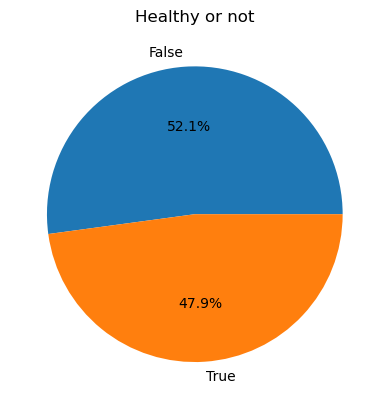

In [13]:
# balenced or not 
no= df["Target"].value_counts()
plt.pie(no, labels=["False","True"], autopct="%1.1f%%")
plt.title("Healthy or not")
# balenced

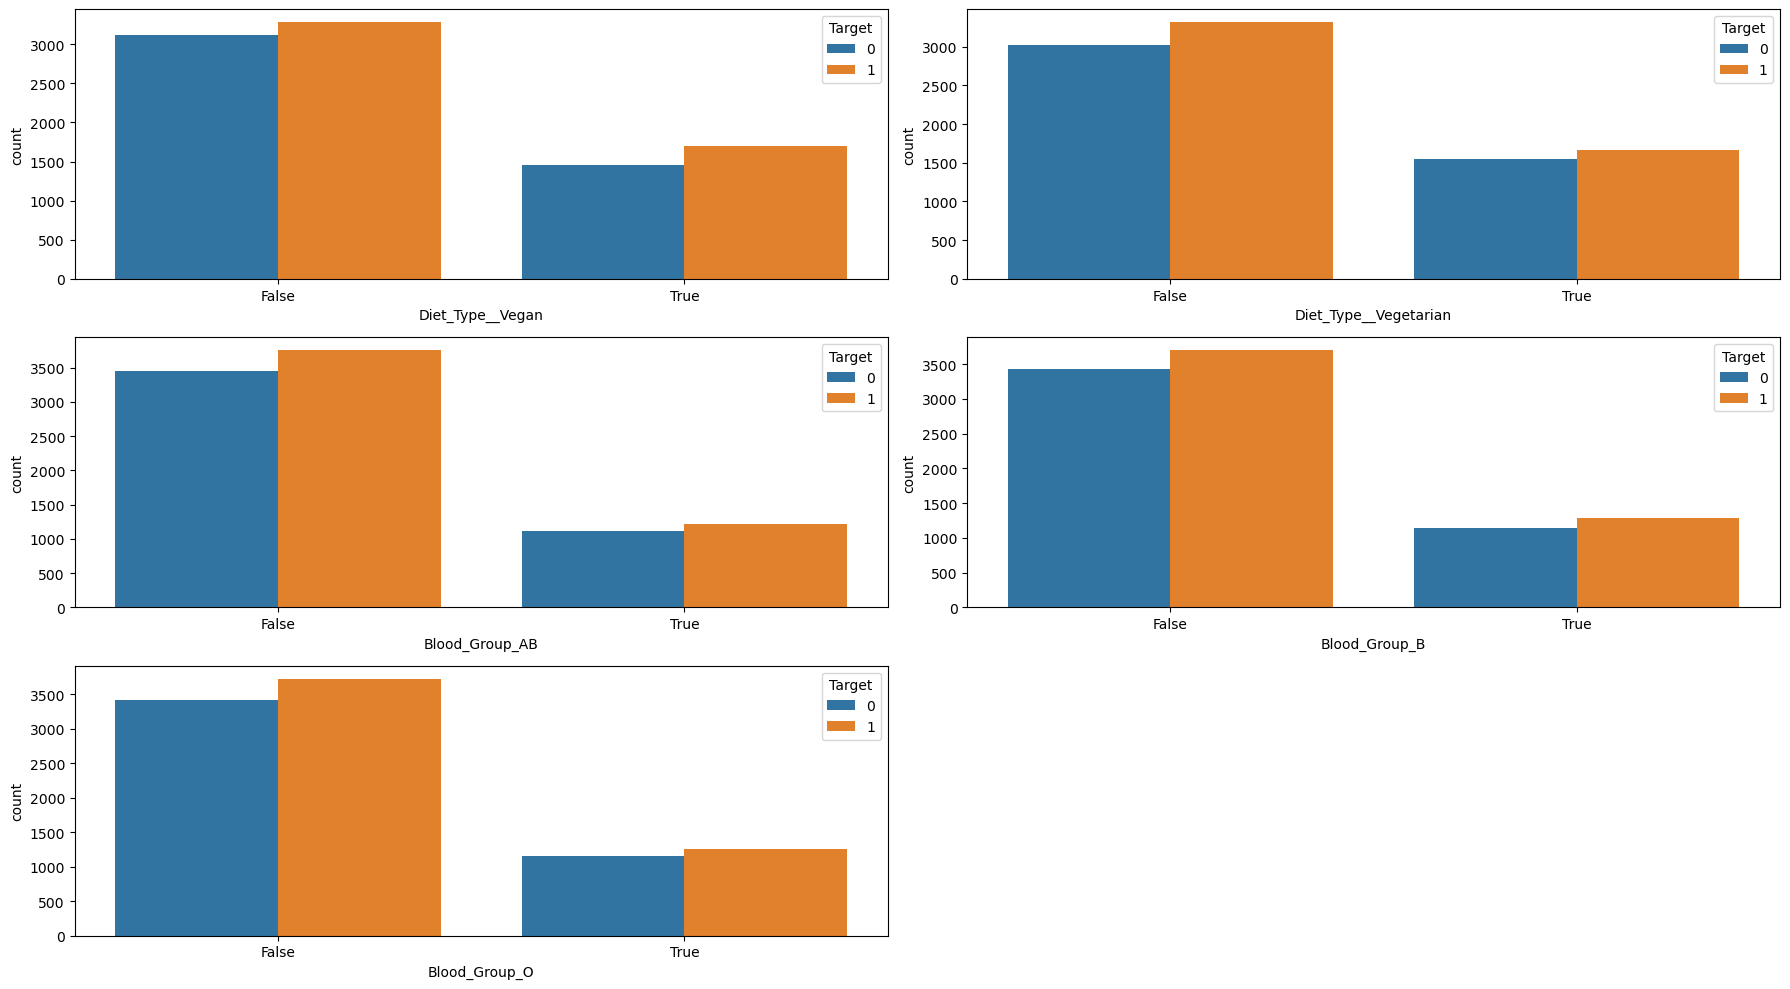

In [15]:
# for categorial data 
fig ,axes= plt.subplots(3,2, figsize= (18,10))

sns.countplot(data=df, x="Diet_Type__Vegan", ax=axes[0,0], hue="Target")
sns.countplot(data=df, x="Diet_Type__Vegetarian", ax=axes[0,1], hue="Target")
sns.countplot(data=df, x="Blood_Group_AB", ax=axes[1,0], hue="Target")
sns.countplot(data=df, x="Blood_Group_B", ax=axes[1,1] , hue="Target")
sns.countplot(data=df, x="Blood_Group_O", ax=axes[2,0] , hue="Target")

axes[2,1].axis("off")

plt.tight_layout()

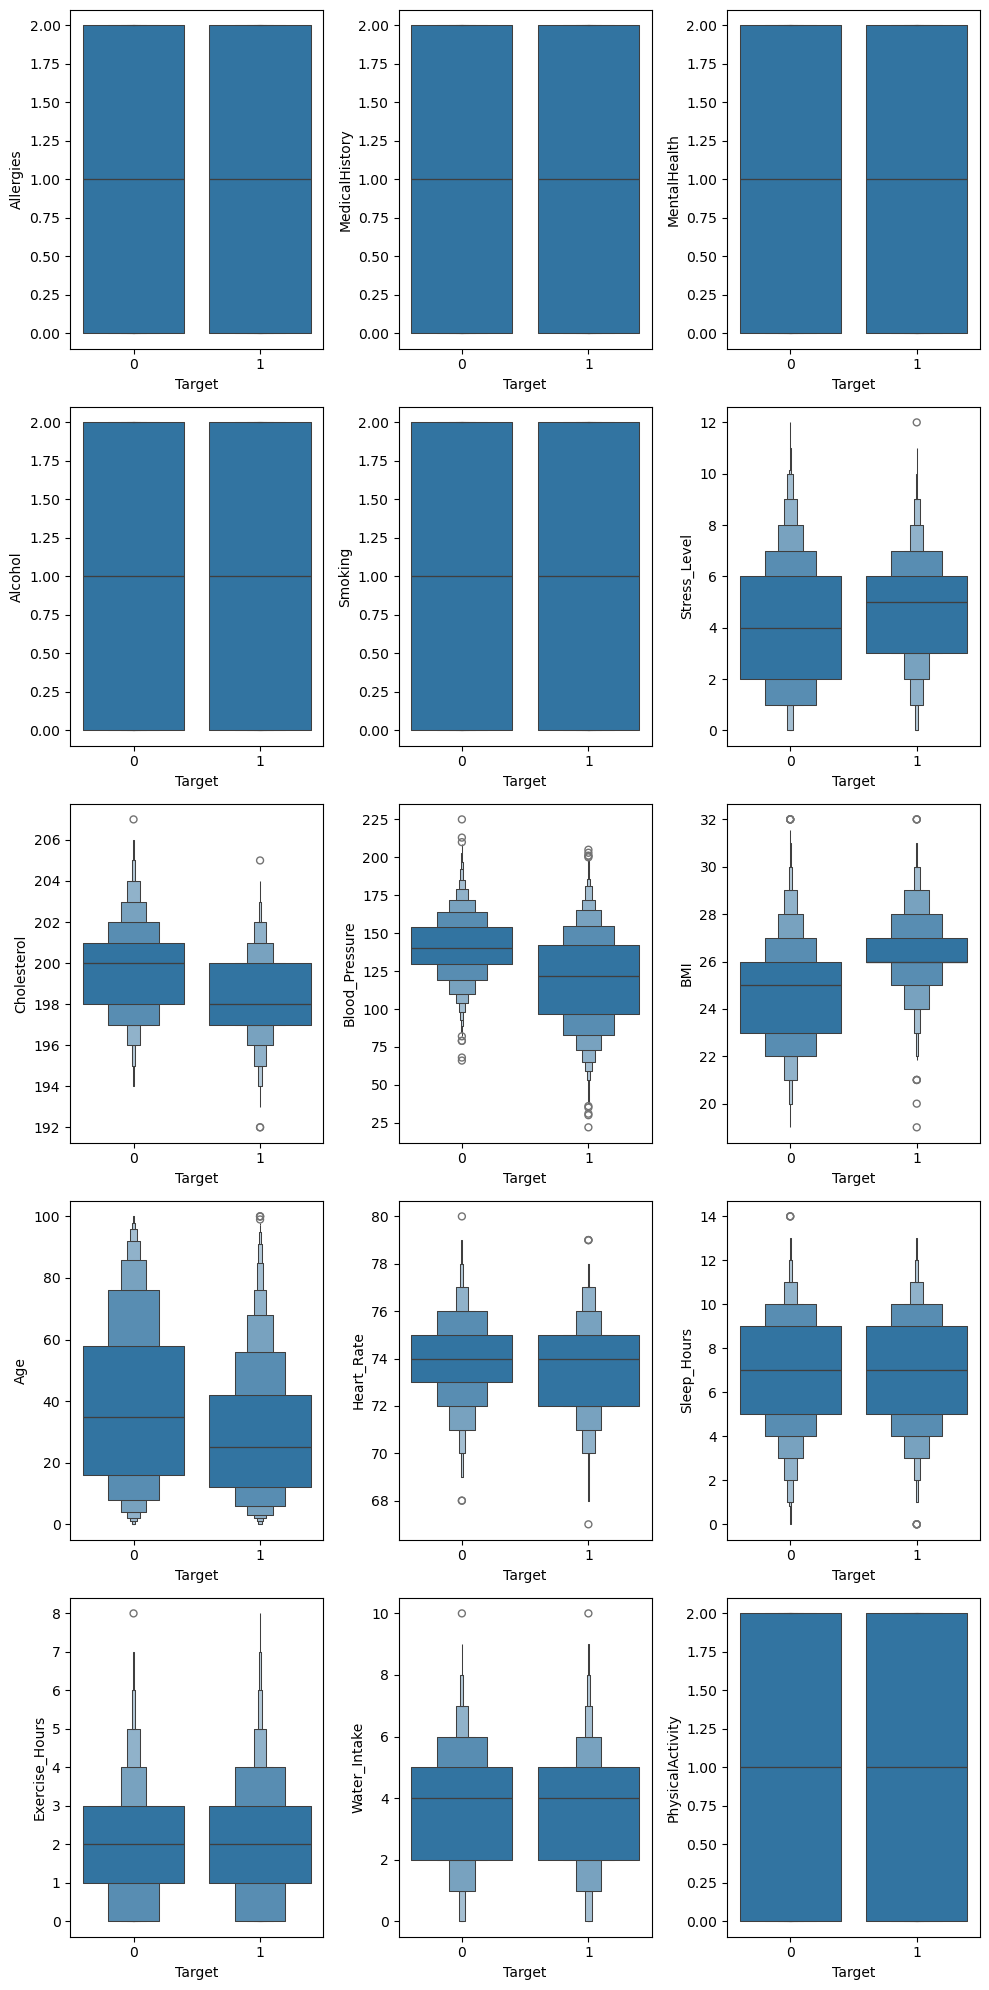

In [17]:
# finding relation in all numerical data 
fig ,axes= plt.subplots(5,3, figsize= (10,20))

sns.boxenplot(data=df, y="Allergies", ax=axes[0,0], x="Target")
sns.boxenplot(data=df, y="MedicalHistory", ax=axes[0,1], x="Target")
sns.boxenplot(data=df, y="MentalHealth", ax=axes[0,2], x="Target")
sns.boxenplot(data=df, y="Alcohol", ax=axes[1,0], x="Target")
sns.boxenplot(data=df, y="Smoking", ax=axes[1,1], x="Target")
sns.boxenplot(data=df, y="Stress_Level", ax=axes[1,2], x="Target")
sns.boxenplot(data=df, y="Cholesterol", ax=axes[2,0], x="Target")
sns.boxenplot(data=df, y="Blood_Pressure", ax=axes[2,1], x="Target")
sns.boxenplot(data=df, y="BMI", ax=axes[2,2], x="Target")
sns.boxenplot(data=df, y="Age", ax=axes[3,0], x="Target") 
sns.boxenplot(data=df, y="Heart_Rate", ax=axes[3,1], x="Target") 
sns.boxenplot(data=df, y="Sleep_Hours", ax=axes[3,2], x="Target")
sns.boxenplot(data=df, y="Exercise_Hours", ax=axes[4,0], x="Target") 
sns.boxenplot(data=df, y="Water_Intake", ax=axes[4,1], x="Target")
sns.boxenplot(data=df, y="PhysicalActivity", ax=axes[4,2], x="Target")

plt.tight_layout()

# Feature Eng.

In [32]:
# one hot encoding to see the coorelation heatmap
from sklearn.preprocessing import OneHotEncoder

catagorial_df= df[catagorial_col]
encoder= OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_arr= encoder.fit_transform(catagorial_df)
encoded_df= pd.DataFrame(encoded_arr, columns=encoder.get_feature_names_out(catagorial_col), index=df.index)
final_df= pd.concat([df[numerical_col],encoded_df], axis=1)

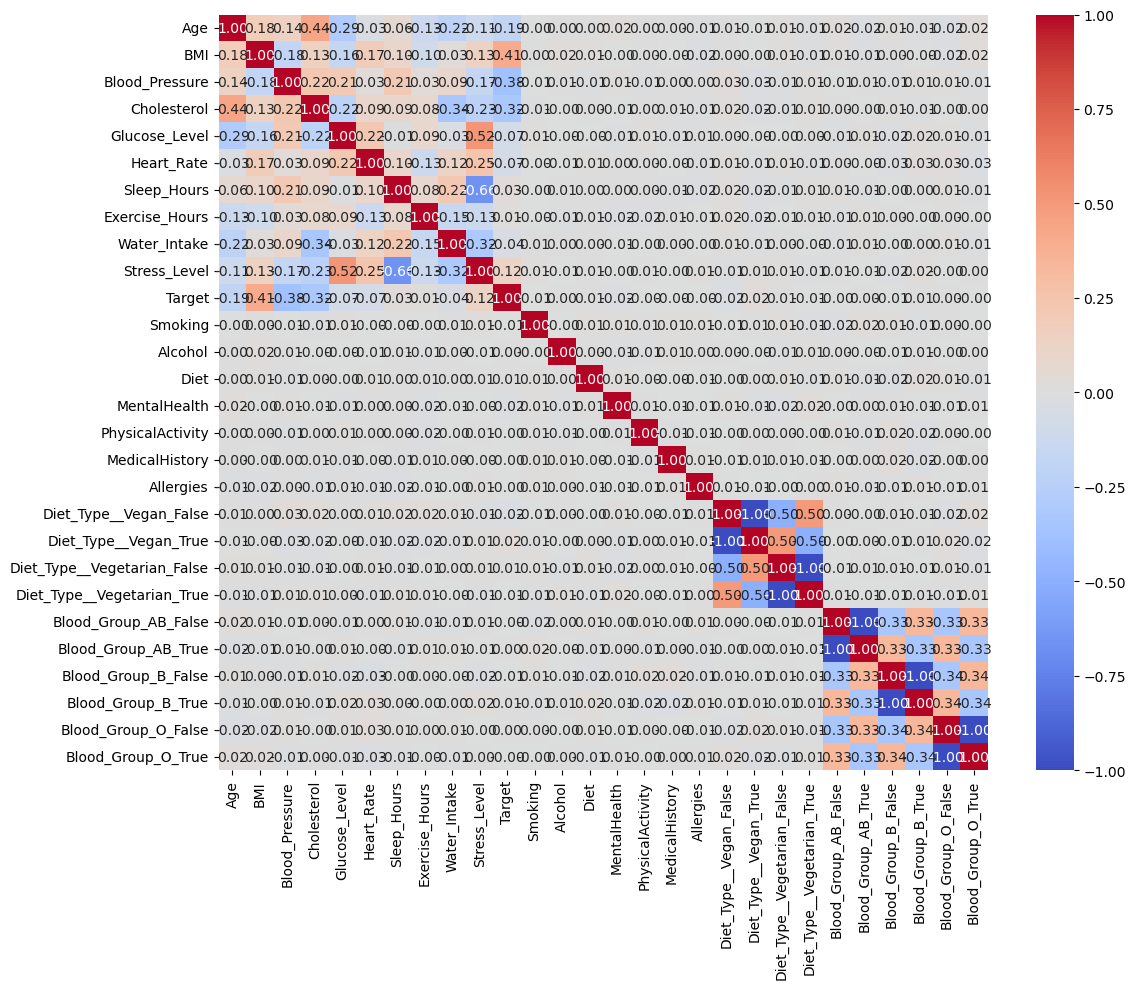

In [34]:
# viewing heatmap
num_col= final_df.select_dtypes(include="number")
corr_mat= num_col.corr()
plt.figure(figsize=(12,10))
sns.heatmap(
    corr_mat, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm"
)

plt.tight_layout()

In [38]:
# Dropind unnecesary features 
X = final_df[["Age","BMI","Blood_Pressure","Stress_Level","Cholesterol"]]
y= final_df["Target"]

# Model Training

In [41]:
X_train, X_test ,y_train ,y_test= train_test_split(X,y, test_size=0.2, random_state=42)

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(
    n_estimators=201, 
    oob_score=True, 
    random_state=42
)

rf.fit(X_train,y_train)
y_pred= rf.predict(X_test)

print("oob:",rf.oob_score_)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))

oob: 0.885718025919623
Accuracy: 0.8884816753926702
f1: 0.8948148148148148


In [63]:
# boosting
import xgboost as xgb 

xgb_class= xgb.XGBClassifier(
    n_estimators= 2001, 
    eval_metric= "logloss",
    learning_rate= 0.1, 
    random_state= 42
)

In [65]:
xgb_class.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2001, n_jobs=None,
              num_parallel_tree=None, ...)

In [67]:
y_pred= xgb_class.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))

Accuracy: 0.8842931937172774
f1: 0.8915071183112421
